训练数据集条数 60000
测试数据集条数 10000


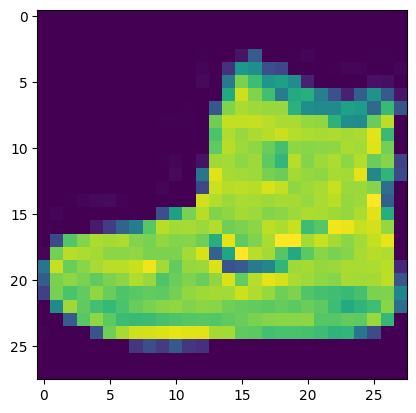

该图片的标签为： 9


In [1]:
import torchvision
import torchvision.transforms as tranforms
data_dir = './fashion_mnist/'
tranform = tranforms.Compose([tranforms.ToTensor()])
train_dataset = torchvision.datasets.FashionMNIST(data_dir, train=True, transform=tranform,download=True)

print("训练数据集条数",len(train_dataset))
val_dataset  = torchvision.datasets.FashionMNIST(root=data_dir, train=False, transform=tranform)
print("测试数据集条数",len(val_dataset))
import pylab
im = train_dataset[0][0]
im = im.reshape(-1,28)
pylab.imshow(im)
pylab.show()
print("该图片的标签为：",train_dataset[0][1])

样本形状： torch.Size([10, 1, 28, 28])
样本标签： tensor([2, 1, 0, 7, 2, 9, 9, 8, 4, 9])
Pullover,Trouser,T-shirt,Sneaker,Pullover,Ankle_Boot,Ankle_Boot,  Bag, Coat,Ankle_Boot


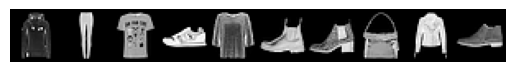

In [2]:
import torch
batch_size = 10
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False)


from matplotlib import pyplot as plt
import numpy as np
def imshow(img):
#    print("图片形状：",np.shape(img))
    npimg = img.numpy()
    plt.axis('off')
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
#    plt.imshow(npimg)

classes = ('T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle_Boot')
sample = iter(train_loader)
images, labels = next(sample)
print('样本形状：',np.shape(images))
print('样本标签：',labels)
imshow(torchvision.utils.make_grid(images,nrow=batch_size))
print(','.join('%5s' % classes[labels[j]] for j in range(len(images))))

In [3]:
from torch.nn import functional as F

class ConNet(torch.nn.Module):
    def __init__(self):
        super(ConNet, self).__init__()
        #定义卷积层
        self.conv1 = torch.nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5)
        self.conv2 = torch.nn.Conv2d(in_channels=6, out_channels=12, kernel_size=5)
        #定义全连接层
        self.fc1 = torch.nn.Linear(in_features=12*4*4, out_features=120)
        self.fc2 = torch.nn.Linear(in_features=120, out_features=60)
        self.out = torch.nn.Linear(in_features=60, out_features=10)

    def forward(self, t):#搭建正向结构
        #第一层卷积和池化处理
        t = self.conv1(t)
        t = F.relu(t)
        t = F.max_pool2d(t, kernel_size=2, stride=2)
        #第二层卷积和池化处理
        t = self.conv2(t)
        t = F.relu(t)
        t = F.max_pool2d(t, kernel_size=2, stride=2)

        #搭建全连接网络，第一层全连接
        t = t.reshape(-1, 12 * 4 * 4)#将卷积结果由4维变为2维
        t = self.fc1(t)
        t = F.relu(t)
        #第二层全连接
        t = self.fc2(t)
        t = F.relu(t)
        #第三层全连接
        t = self.out(t)
        return t

In [4]:
network = ConNet()
print(network)#打印网络



##指定设备
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

ConNet(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(6, 12, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=192, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=60, bias=True)
  (out): Linear(in_features=60, out_features=10, bias=True)
)
cuda:0


In [5]:
network.to(device)

criterion = torch.nn.CrossEntropyLoss()  #实例化损失函数类
optimizer = torch.optim.Adam(network.parameters(), lr=.01)


for epoch in range(2): #数据集迭代2次
    running_loss = 0.0
    for i, data in enumerate(train_loader): #循环取出批次数据
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device) #
        optimizer.zero_grad()#清空之前的梯度
        outputs = network(inputs)
        loss = criterion(outputs, labels)#计算损失
        loss.backward()  #反向传播
        optimizer.step() #更新参数

        running_loss += loss.item()
        if i % 1000 == 999:
            print('[%d, %5d] loss: %.3f' %
                (epoch + 1, i + 1, running_loss / 2000))
            running_loss = 0.0

print('Finished Training')
# 保存模型
torch.save(network.state_dict(), './CNNFashionMNIST.pth')

[1,  1000] loss: 0.413
[1,  2000] loss: 0.285
[1,  3000] loss: 0.277
[1,  4000] loss: 0.271
[1,  5000] loss: 0.268
[1,  6000] loss: 0.269
[2,  1000] loss: 0.250
[2,  2000] loss: 0.257
[2,  3000] loss: 0.249
[2,  4000] loss: 0.257
[2,  5000] loss: 0.269
[2,  6000] loss: 0.253
Finished Training


真实标签:  Ankle_Boot Pullover Trouser Trouser Shirt Trouser  Coat Shirt Sandal Sneaker
tensor([[-1.4627e+01, -2.8522e+01, -1.0358e+01, -1.3803e+01, -1.6449e+01,
          4.9814e-02, -1.3605e+01,  1.0321e+00, -6.7438e+00,  5.2794e+00],
        [-2.2946e+00, -4.4583e+00,  3.4693e+00, -5.5483e+00, -8.7231e-01,
         -2.0220e+01, -2.6589e-01, -2.9526e+01, -3.2047e+00, -1.0268e+01],
        [-2.7709e+00,  5.9551e+00, -2.7541e+00, -4.3840e+00, -5.7869e+00,
         -2.5237e+01, -1.5496e+00, -7.0679e+01, -9.3508e+00, -4.7143e+01],
        [-1.5416e+00,  4.0284e+00, -3.6946e+00, -1.4723e-01, -3.3035e+00,
         -1.3522e+01, -2.4888e+00, -2.8523e+01, -3.8363e+00, -2.7343e+01],
        [-1.0544e-01, -2.8802e+00, -3.0095e-01, -1.0094e+00, -1.7510e+00,
         -7.9233e+00,  4.4535e-02, -1.3689e+01, -2.4012e+00, -1.0172e+01],
        [-2.5617e+00,  8.3680e+00, -3.9571e+00, -5.2500e+00, -9.2246e+00,
         -3.3429e+01, -2.7928e+00, -8.9582e+01, -1.1662e+01, -6.3553e+01],
        [-3.7166e+00, 

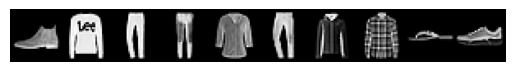

In [6]:
network.load_state_dict(torch.load( './CNNFashionMNIST.pth'))#加载模型

#使用模型
dataiter = iter(test_loader)
images, labels = next(dataiter)
inputs, labels = images.to(device), labels.to(device)

imshow(torchvision.utils.make_grid(images,nrow=batch_size))
print('真实标签: ', ' '.join('%5s' % classes[labels[j]] for j in range(len(images))))
outputs = network(inputs)
print(outputs) 

In [7]:
#测试模型
class_correct = list(0. for i in range(10))
class_total = list(0. for i in range(10))
with torch.no_grad():
    for data in test_loader:
        images, labels = data
        inputs, labels = images.to(device), labels.to(device)
        outputs = network(inputs)
        _, predicted = torch.max(outputs, 1)
        predicted = predicted.to(device)
        c = (predicted == labels).squeeze()
        print(c)
        for i in range(10):
            label = labels[i]
            class_correct[label] += c[i].item()
            class_total[label] += 1

sumacc = 0
for i in range(10):
    Accuracy = 100 * class_correct[i] / class_total[i]
    print('Accuracy of %5s : %2d %%' % (classes[i], Accuracy ))
    sumacc =sumacc+Accuracy
print('Accuracy of all : %2d %%' % ( sumacc/10. ))
_, predicted = torch.max(outputs, 1)


tensor([True, True, True, True, True, True, True, True, True, True],
       device='cuda:0')
tensor([True, True, True, True, True, True, True, True, True, True],
       device='cuda:0')
tensor([ True,  True,  True, False,  True, False,  True, False,  True, False],
       device='cuda:0')
tensor([True, True, True, True, True, True, True, True, True, True],
       device='cuda:0')
tensor([False,  True,  True, False, False,  True,  True,  True, False, False],
       device='cuda:0')
tensor([ True,  True,  True,  True, False,  True,  True,  True,  True,  True],
       device='cuda:0')
tensor([ True,  True,  True,  True,  True,  True, False, False, False,  True],
       device='cuda:0')
tensor([ True,  True,  True, False, False,  True,  True,  True,  True,  True],
       device='cuda:0')
tensor([ True,  True,  True,  True,  True,  True,  True, False,  True, False],
       device='cuda:0')
tensor([True, True, True, True, True, True, True, True, True, True],
       device='cuda:0')
tensor([ T

tensor([ True,  True,  True, False,  True,  True,  True,  True,  True,  True],
       device='cuda:0')
tensor([ True, False,  True,  True,  True,  True,  True,  True,  True,  True],
       device='cuda:0')
tensor([False,  True,  True, False, False,  True,  True,  True, False,  True],
       device='cuda:0')
tensor([ True,  True, False,  True,  True,  True,  True,  True,  True, False],
       device='cuda:0')
tensor([ True,  True,  True,  True,  True,  True, False,  True,  True,  True],
       device='cuda:0')
tensor([ True, False,  True,  True,  True,  True,  True,  True,  True,  True],
       device='cuda:0')
tensor([False,  True,  True,  True,  True,  True,  True,  True, False,  True],
       device='cuda:0')
tensor([True, True, True, True, True, True, True, True, True, True],
       device='cuda:0')
tensor([ True,  True,  True,  True,  True,  True, False,  True,  True,  True],
       device='cuda:0')
tensor([False,  True,  True, False,  True, False, False,  True, False,  True],
    

tensor([ True,  True,  True,  True,  True,  True, False,  True,  True,  True],
       device='cuda:0')
tensor([ True, False,  True,  True,  True,  True, False, False, False,  True],
       device='cuda:0')
tensor([ True,  True,  True,  True, False,  True,  True,  True,  True,  True],
       device='cuda:0')
tensor([ True,  True, False,  True,  True,  True, False,  True,  True,  True],
       device='cuda:0')
tensor([ True,  True, False,  True,  True,  True,  True,  True,  True,  True],
       device='cuda:0')
tensor([ True,  True,  True,  True, False,  True,  True,  True,  True,  True],
       device='cuda:0')
tensor([ True,  True,  True,  True,  True, False,  True,  True,  True,  True],
       device='cuda:0')
tensor([False, False,  True,  True,  True, False,  True,  True,  True, False],
       device='cuda:0')
tensor([False, False, False,  True,  True,  True,  True,  True,  True,  True],
       device='cuda:0')
tensor([True, True, True, True, True, True, True, True, True, True],
    

tensor([ True,  True, False,  True,  True, False,  True,  True,  True, False],
       device='cuda:0')
tensor([False,  True,  True,  True,  True,  True,  True, False, False,  True],
       device='cuda:0')
tensor([ True,  True,  True,  True, False,  True,  True,  True,  True,  True],
       device='cuda:0')
tensor([ True,  True,  True, False, False,  True, False, False,  True,  True],
       device='cuda:0')
tensor([ True, False,  True,  True,  True,  True,  True,  True,  True,  True],
       device='cuda:0')
tensor([ True,  True,  True, False,  True, False,  True,  True,  True,  True],
       device='cuda:0')
tensor([ True,  True,  True, False,  True,  True,  True, False,  True,  True],
       device='cuda:0')
tensor([ True,  True,  True,  True, False,  True,  True,  True, False,  True],
       device='cuda:0')
tensor([ True,  True, False,  True, False,  True,  True,  True,  True, False],
       device='cuda:0')
tensor([True, True, True, True, True, True, True, True, True, True],
    

tensor([ True,  True, False,  True,  True,  True,  True,  True,  True,  True],
       device='cuda:0')
tensor([False,  True,  True,  True, False, False, False,  True,  True, False],
       device='cuda:0')
tensor([False,  True, False,  True,  True,  True,  True,  True,  True,  True],
       device='cuda:0')
tensor([ True,  True,  True,  True, False,  True,  True,  True, False,  True],
       device='cuda:0')
tensor([ True,  True,  True,  True, False,  True, False,  True, False,  True],
       device='cuda:0')
tensor([False,  True, False, False,  True, False,  True,  True, False,  True],
       device='cuda:0')
tensor([ True,  True,  True, False,  True,  True,  True,  True,  True, False],
       device='cuda:0')
tensor([False,  True,  True,  True, False, False,  True, False,  True, False],
       device='cuda:0')
tensor([ True,  True,  True,  True,  True,  True,  True,  True, False,  True],
       device='cuda:0')
tensor([True, True, True, True, True, True, True, True, True, True],
    

tensor([False,  True,  True,  True,  True,  True, False,  True,  True,  True],
       device='cuda:0')
tensor([False,  True,  True,  True,  True,  True,  True,  True, False,  True],
       device='cuda:0')
tensor([False,  True, False,  True,  True,  True,  True,  True,  True,  True],
       device='cuda:0')
tensor([ True,  True,  True,  True,  True, False,  True, False,  True,  True],
       device='cuda:0')
tensor([ True,  True,  True,  True, False,  True,  True,  True,  True,  True],
       device='cuda:0')
tensor([ True,  True,  True,  True,  True,  True, False,  True,  True,  True],
       device='cuda:0')
tensor([ True,  True,  True,  True,  True, False,  True, False,  True,  True],
       device='cuda:0')
tensor([ True,  True,  True,  True, False,  True,  True,  True, False, False],
       device='cuda:0')
tensor([ True,  True,  True,  True,  True, False,  True,  True,  True,  True],
       device='cuda:0')
tensor([ True,  True, False,  True,  True,  True,  True,  True,  True,  T

tensor([False,  True,  True,  True,  True,  True,  True,  True,  True,  True],
       device='cuda:0')
tensor([ True,  True,  True, False,  True,  True,  True, False,  True,  True],
       device='cuda:0')
tensor([ True,  True,  True,  True, False,  True,  True,  True,  True,  True],
       device='cuda:0')
tensor([False,  True, False,  True,  True,  True,  True,  True,  True,  True],
       device='cuda:0')
tensor([ True,  True,  True,  True, False,  True,  True,  True,  True,  True],
       device='cuda:0')
tensor([ True,  True,  True,  True, False,  True,  True,  True,  True,  True],
       device='cuda:0')
tensor([True, True, True, True, True, True, True, True, True, True],
       device='cuda:0')
tensor([ True, False,  True,  True,  True,  True,  True,  True,  True, False],
       device='cuda:0')
tensor([False,  True,  True,  True,  True,  True,  True,  True,  True, False],
       device='cuda:0')
tensor([ True, False,  True,  True, False,  True,  True,  True, False,  True],
    

tensor([ True,  True,  True,  True,  True, False, False, False,  True,  True],
       device='cuda:0')
tensor([ True, False,  True, False,  True,  True,  True,  True,  True,  True],
       device='cuda:0')
tensor([ True,  True,  True,  True,  True, False,  True,  True,  True,  True],
       device='cuda:0')
tensor([ True, False,  True,  True,  True, False,  True,  True, False,  True],
       device='cuda:0')
tensor([ True,  True,  True,  True,  True, False,  True,  True,  True,  True],
       device='cuda:0')
tensor([ True,  True,  True,  True,  True,  True, False,  True,  True,  True],
       device='cuda:0')
tensor([ True, False,  True, False,  True,  True,  True, False,  True,  True],
       device='cuda:0')
tensor([ True, False, False,  True,  True,  True,  True,  True, False,  True],
       device='cuda:0')
tensor([ True,  True, False, False, False,  True,  True,  True,  True,  True],
       device='cuda:0')
tensor([ True,  True,  True, False,  True,  True,  True,  True,  True,  T

tensor([ True,  True,  True,  True,  True,  True,  True,  True,  True, False],
       device='cuda:0')
tensor([ True,  True, False, False,  True,  True,  True,  True,  True, False],
       device='cuda:0')
tensor([ True,  True,  True,  True,  True, False,  True,  True,  True,  True],
       device='cuda:0')
tensor([False,  True, False,  True, False,  True,  True, False, False,  True],
       device='cuda:0')
tensor([False,  True,  True,  True,  True,  True,  True,  True,  True,  True],
       device='cuda:0')
tensor([True, True, True, True, True, True, True, True, True, True],
       device='cuda:0')
tensor([False,  True,  True,  True,  True,  True,  True, False,  True,  True],
       device='cuda:0')
tensor([True, True, True, True, True, True, True, True, True, True],
       device='cuda:0')
tensor([False,  True,  True,  True,  True,  True,  True,  True,  True,  True],
       device='cuda:0')
tensor([ True,  True, False,  True,  True,  True,  True, False, False,  True],
       device=

tensor([False, False,  True,  True, False,  True, False,  True,  True,  True],
       device='cuda:0')
tensor([ True,  True, False,  True, False,  True,  True,  True,  True,  True],
       device='cuda:0')
tensor([ True,  True,  True,  True,  True, False,  True,  True,  True,  True],
       device='cuda:0')
tensor([ True,  True,  True,  True,  True,  True,  True, False,  True,  True],
       device='cuda:0')
tensor([ True,  True,  True,  True,  True,  True,  True, False, False,  True],
       device='cuda:0')
tensor([ True,  True, False,  True,  True,  True,  True,  True,  True,  True],
       device='cuda:0')
tensor([True, True, True, True, True, True, True, True, True, True],
       device='cuda:0')
tensor([ True,  True,  True, False,  True,  True,  True,  True,  True,  True],
       device='cuda:0')
tensor([ True,  True,  True,  True,  True,  True,  True,  True, False,  True],
       device='cuda:0')
tensor([ True, False,  True, False,  True, False,  True,  True,  True, False],
    